# Kaggle - Brain Tumor MRI Dataset

You can find the dataset and some informations about on the [Kaggle page](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

For details on steps below, please see documentation in the *docs* directory.

## Kaggle notebook setup
### Installations

In [1]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 65.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 66.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beha

### Data location

In [2]:
import os
print(os.listdir('/kaggle/input/'))
print(os.listdir('/kaggle/input/radimagenet-densenet121-notop'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed/processed'))

['radimagenet-densenet121-notop', 'brain-tumor-mri-preprocessed']
['RadImageNet-DenseNet121_notop.h5']
['processed']
['Validation', 'Training', 'Testing', '.gitkeep']


## General

In [3]:
import mlflow
import mlflow.tensorflow
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri("https://preachingly-nonabjuratory-marget.ngrok-free.dev")
mlflow.set_experiment("Brain_Tumor_Training")

2026-02-06 09:29:02.634855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770370142.815960      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770370142.870528      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770370143.308966      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770370143.309015      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770370143.309018      55 computation_placer.cc:177] computation placer alr

<Experiment: artifact_location='mlflow-artifacts:/830660600119881173', creation_time=1769099937797, experiment_id='830660600119881173', last_update_time=1769099937797, lifecycle_stage='active', name='Brain_Tumor_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [44]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import math

import cv2
from collections import defaultdict

In [5]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

Num GPUs Available: 1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [42]:
# path management
PROJECT_ROOT = '/kaggle/input'
PREP_DIR = PROJECT_ROOT + '/brain-tumor-mri-preprocessed/processed'
ARTEFACTS_DIR = PROJECT_ROOT + '/radimagenet-densenet121-notop'
OUTPUT_DIR = "kaggle/working/radcam_results"
os.makedirs(OUTPUT_DIR + "/correct", exist_ok=True)
os.makedirs(OUTPUT_DIR + "/errors", exist_ok=True)

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_DIR = "/kaggle/working/export_model"
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES = ["notumor", "glioma", "meningioma", "pituitary"]

# model parameters
IMG_SIZE = 260
SEED = 42

PROJECT_NAME = "BrainTumorMRI"
MODEL_TYPE = "DenseNet121"
TWO_HEAD = True
MODEL_NAME = f"{PROJECT_NAME}_{MODEL_TYPE}_{TWO_HEAD*"2Head"}"
FREEZE_BACKBONE = True
MASK_TUMOR_TYPE_LOSS = True
BATCH_SIZE = 32
DATA_AUGMENTATION = True

# grad-cam parameters
LAST_CONV_LAYER = "conv5_block16_concat"
BACKBONE_NAME = "densenet121"

## Modeling

### Backbone

In [7]:
# 1. Create DenseNet121 WITHOUT weights
backbone = DenseNet121(
    include_top=False,
    weights=None,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Load RadImageNet weights
backbone.load_weights(ARTEFACTS_DIR + "/RadImageNet-DenseNet121_notop.h5")

# 3. Freeze the backbone for firsts training
backbone.trainable = not FREEZE_BACKBONE

print("✅ RadImageNet DenseNet121 loaded successfully")

I0000 00:00:1770370181.231976      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ RadImageNet DenseNet121 loaded successfully


In [8]:
#backbone.summary()

In [9]:
w = backbone.weights[0].numpy()
print("Mean:", np.mean(w), "Std:", np.std(w))

Mean: -0.0028284893 Std: 0.10494729


Model seems to be correctly loaded.

### Model definition

In [10]:
model_data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomZoom((-0.03,0.03),(-0.03,0.03), seed=SEED),
    layers.RandomTranslation((-0.01,0.01),(-0.01,0.01), seed=SEED),
], name='data_augmentation_part')

In [11]:
model_head1 = keras.Sequential([
    layers.Dense(128, use_bias=False), # TO TEST : 256 ?
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    layers.Dense(1,activation='sigmoid')
], name='tumor_presence')

In [12]:
model_head2 = keras.Sequential([
    layers.Dense(128, use_bias=False), # TO TEST : 256 ?
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    layers.Dense(4,activation='softmax')
], name='tumor_type')

In [13]:
def shared_head_part(inputs, backbone, data_augmentation):
    # Data augmentation (training only)
    x = data_augmentation(inputs)
    # Backbone - force into inference
    x = backbone(x, training=False)

    # Shared head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    return x

In [14]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = shared_head_part(inputs, backbone, model_data_augmentation)

#Heads
output_presence = model_head1(x)
output_type = model_head2(x)

model = keras.Model(
    inputs=inputs,
    outputs={
        "tumor_presence": output_presence,
        "tumor_type": output_type
    },
    name='densenet_two_head'
)

In [15]:
loss_presence = keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,
    alpha=0.25 # to favorize tumor detection (penalize false negatives), but taking account that tumors are 75% of data
)

In [16]:
#@keras.saving.register_keras_serializable()
@tf.keras.utils.register_keras_serializable()
def masked_sparse_cce(y_true, y_pred):
    tumor_present = tf.cast(y_true != 0, tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    loss = loss * tumor_present
    return tf.reduce_sum(loss) / (tf.reduce_sum(tumor_present) + 1e-6)

In [17]:
loss_weight_presence = 1.0
loss_weight_type = 1.3 # we give a little more weight to the classification of the type

model.compile(
    optimizer=keras.optimizers.Adam(), # change learning_rate for 1e-4 in fine-tuning steps
    loss={
        "tumor_presence": loss_presence,
        "tumor_type": masked_sparse_cce,
    },
    
    loss_weights={
        "tumor_presence": loss_weight_presence,
        "tumor_type": loss_weight_type, 
    },
    
    metrics={
        "tumor_presence": [
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.Precision(name="precision"),
            #keras.metrics.F1Score(name="f1_score"),
            keras.metrics.AUC(name="auc")
        ],
        "tumor_type": [
            "accuracy", 
            #"f1_score"
        ],
    }
)

In [18]:
#model.summary()

## Streaming Training

In [19]:
def parse_tfrecord(example_proto):
    """
    Parse a single TFRecord example and convert grayscale → RGB.
    """
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }

    example = tf.io.parse_single_example(example_proto, feature_description)

    # Deserialize image
    image = tf.io.parse_tensor(example["image"], out_type=tf.float32)

    # Shape after loading: (260, 260, 3)
    image.set_shape((260, 260, 3))

    label = tf.cast(example["label"], tf.int32)

    return image, label



def load_tfrecord_dataset(tfrecord_dir, shuffle=False, batch_size=1, repeat=False):
    """
    Load a TFRecord dataset from a directory.

    Args:
        tfrecord_dir (str or Path): Folder containing .tfrecord files
        shuffle (bool): Whether to shuffle files and samples
        batch_size (int): Batch size (can stay 1)
        repeat (bool): Repeat dataset indefinitely (for training)

    Returns:
        tf.data.Dataset
    """
    tfrecord_files = tf.io.gfile.glob(
        str(tfrecord_dir) + "/*.tfrecord"
    )

    ds = tf.data.TFRecordDataset(
        tfrecord_files,
        num_parallel_reads=tf.data.AUTOTUNE
    )

    ds = ds.map(
        parse_tfrecord,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=512)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [20]:
TRAIN_DIR = PREP_DIR + "/Training"
VAL_DIR   = PREP_DIR + "/Validation"
TEST_DIR  = PREP_DIR + "/Testing"

train_ds = load_tfrecord_dataset(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

"""
test_ds = load_tfrecord_dataset(
    TEST_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)
"""

'\ntest_ds = load_tfrecord_dataset(\n    TEST_DIR,\n    shuffle=False,\n    batch_size=BATCH_SIZE,\n    repeat=False\n).prefetch(tf.data.AUTOTUNE)\n'

In [21]:
def split_labels(image, label):
    """
    Create labels for a 2-head model.
    """
    tumor_present = tf.cast(label != 0, tf.float32)
    tumor_type = tf.cast(label, tf.int32)

    return image, {
        "tumor_presence": tumor_present,
        "tumor_type": tumor_type
    }


In [22]:
train_ds = train_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [23]:
#for x, y in train_ds.take(1):
#    print("Image:")
#    print(x.dtype, x.shape)
#    print("\nLabels:")
#    for k, v in y.items():
#        print(k, v.dtype, v.shape)

In [24]:
def count_tfrecord_batches(directory_path, batch_size):
    """
    Count number of batches for a TFRecord dataset.

    Assumes:
    - 1 sample per TFRecord
    - batch_size is variable

    Returns:
    - number of batches = ceil(num_samples / batch_size)
    """
    directory_path = Path(directory_path)
    n_samples = len(list(directory_path.glob("*.tfrecord")))
    return math.ceil(n_samples / batch_size)


In [25]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name=None), {'tumor_presence': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'tumor_type': TensorSpec(shape=(None,), dtype=tf.int32, name=None)})


In [26]:
#to_monitor = "val_tumor_presence_recall"
#mode = "max"
to_monitor = "val_tumor_type_loss"
mode = "min"

reduce_lr = ReduceLROnPlateau(
    monitor=to_monitor,
    mode=mode,
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor=to_monitor,
    mode=mode,
    min_delta=0.0001,
    patience=10,
    restore_best_weights=False,
    verbose=1,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR + "/epoch_{epoch:02d}.weights.h5",
    monitor=to_monitor,
    mode=mode,
    save_best_only=False,
    save_weights_only=True,
    verbose=1,
)

terminate_nan = keras.callbacks.TerminateOnNaN()

In [27]:
#print("RUN_NAME:", RUN_NAME)
#print("TRAIN steps:", count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE))
#print("VAL steps:", count_tfrecord_batches(VAL_DIR, BATCH_SIZE))
#print("train_ds element_spec:", train_ds.element_spec)

In [28]:
raise Exception("Do not fit from scratch again. Use the best head model !")

RUN_NAME = (
    f"{MODEL_TYPE}"
    f"freeze={FREEZE_BACKBONE}_"
    f"mask={MASK_TUMOR_TYPE_LOSS}_"
    f"{datetime.now().strftime('%Y%m%d-%H%M')}"
)

print(f"Run name: {RUN_NAME}\n")

with mlflow.start_run(run_name=RUN_NAME):

    mlflow.tensorflow.autolog(registered_model_name=MODEL_NAME)

    mlflow.log_params({
        "project": PROJECT_NAME,
        "model_type": MODEL_TYPE,
        "pretrained_weights": "RadImageNet",
        "backbone_frozen": FREEZE_BACKBONE,
        "head_1": "tumor_presence_binary",
        "head_2": "tumor_type_softmax",
        "loss_weight_presence": loss_weight_presence,
        "loss_weight_type": loss_weight_type,
        "mask_tumor_type_loss": MASK_TUMOR_TYPE_LOSS,
        "label_0_means": "no_tumor",
        "data_augmentation": DATA_AUGMENTATION,
    })

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=60,
        #steps_per_epoch=count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE),
        #validation_steps=count_tfrecord_batches(VAL_DIR, BATCH_SIZE),
        callbacks=[reduce_lr, early_stopping, checkpoint_cb, terminate_nan],
        verbose=1,
    )

    client = MlflowClient()
    latest_version = client.get_latest_versions(MODEL_NAME)[-1].version

    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=latest_version,
        stage="Staging"
    )


Exception: Do not fit from scratch again. Use the best head model !

## Epoch filter

In [ ]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index
#history_df.head(5)

In [ ]:
metrics_cols = [
    "epoch",
    "val_tumor_presence_recall",
    "val_tumor_type_accuracy",
    "val_tumor_presence_loss",
    "val_tumor_type_loss"
]

df = history_df[metrics_cols].copy()

In [ ]:
df = df[
    (df["val_tumor_presence_recall"] >= 0.94) &
    (df["val_tumor_type_accuracy"] >= 0.55)
]
#df

In [ ]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-8)

df["pres_rec_norm"] = normalize(df["val_tumor_presence_recall"])
df["type_accu_norm"] = normalize(df["val_tumor_type_accuracy"])
df["pres_loss_norm"] = 1 - normalize(df["val_tumor_presence_loss"])
df["type_loss_norm"] = 1 - normalize(df["val_tumor_type_loss"])

In [ ]:
df["S"] = (
    0.40 * df["pres_rec_norm"]
  + 0.35 * df["type_accu_norm"]
  + 0.15 * df["pres_loss_norm"]
  + 0.10 * df["type_loss_norm"]
)
#df

In [ ]:
best_row = df.sort_values("S", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])

print(f"✅ Best epoch selected from S: {best_epoch}")
print(best_row)

In [ ]:
mlflow.set_tags({
    "model_stage": "best_manual_epoch",
    "best_epoch": best_epoch,
    "selection_method": "composite_score_S",
})

mlflow.log_metric("S", best_row.iloc[-1])
mlflow.log_metric("Best epoch", best_row.iloc[0])

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.load_weights(f"{CHECKPOINT_DIR}/epoch_{best_epoch:02d}.weights.h5")
print(f"✅ Loaded best epoch: {best_epoch}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
mlflow.tensorflow.log_model(
    model,
    name=f"best_epoch_{best_epoch}_manual",
    registered_model_name=MODEL_NAME
)
print(f"✅ Registered best model: {MODEL_NAME}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.save(f"{MODEL_DIR}/brain_tumor_model_best_epoch_{best_epoch}.keras")
model.save_weights(
    f"{MODEL_DIR}/brain_tumor_weights_epoch_{best_epoch}.weights.h5"
)
mlflow.log_artifacts(MODEL_DIR, artifact_path="exported_model_files")

### Loading final model from MLFlow

In [31]:
model = mlflow.tensorflow.load_model(
    "models:/BrainTumorMRI_DenseNet121_2Head/latest"
)
print("✅ Model loaded successfully with custom loss")

✅ Model loaded successfully with custom loss


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 19 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 15 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [64]:
print(type(model))
print(model.output)
model.summary()

<class 'keras.src.models.functional.Functional'>
{'tumor_presence': <KerasTensor shape=(None, 1), dtype=float16, sparse=False, ragged=False, name=keras_tensor_1418>, 'tumor_type': <KerasTensor shape=(None, 4), dtype=float16, sparse=False, ragged=False, name=keras_tensor_1420>}


Model: "densenet_two_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 260, 260,  │          0 │ input_layer_6[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 8, 8,      │  7,037,504 │ data_augmentatio… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 512)       │    524,288 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tumor_presence      │ (None, 1)         │     66,177 │ dropout_5[0][0]   │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tumor_type          │ (None, 4)         │     66,564 │ dropout_5[0][0]   │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,354,128 (31.87 MB)

 Trainable params: 657,541 (2.51 MB)

 Non-trainable params: 7,039,040 (26.85 MB)

 Optimizer params: 657,547 (2.51 MB)

In [33]:
model.evaluate(val_ds)

I0000 00:00:1770372116.127001     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 0.3289 - tumor_presence_accuracy: 0.9850 - tumor_presence_auc: 0.9958 - tumor_presence_loss: 0.0168 - tumor_presence_precision: 0.9880 - tumor_presence_recall: 0.9916 - tumor_type_accuracy: 0.6632 - tumor_type_loss: 0.2400


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.36767616868019104,
 0.017767449840903282,
 0.26374632120132446,
 0.9816272854804993,
 0.9955679178237915,
 0.9890377521514893,
 0.9854369163513184,
 0.6342957019805908]

### Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

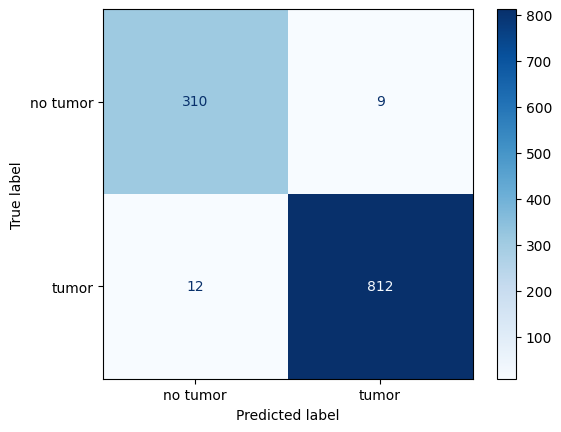

In [35]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_presence'].numpy())
    y_pred_type.extend((preds['tumor_presence'] > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no tumor", "tumor"])
disp.plot(cmap='Blues')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

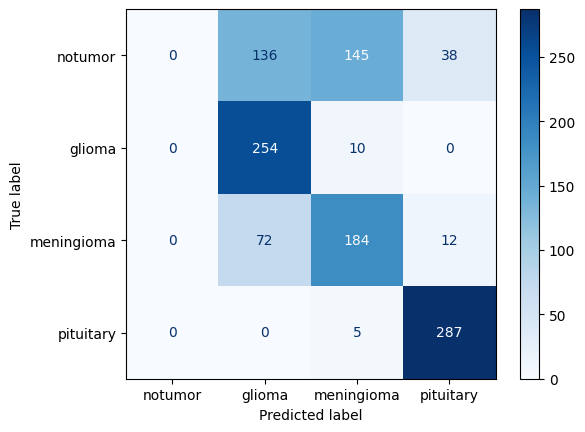

In [36]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_type'].numpy())
    y_pred_type.extend(preds['tumor_type'].argmax(axis=-1))

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')

### Grad-CAM

In [76]:
last_conv_layer = model.get_layer("densenet121").output

gradcam_model = tf.keras.Model(
    inputs=model.input,
    outputs=[
        last_conv_layer,
        model.output["tumor_presence"],
        model.output["tumor_type"],
    ],
)

In [77]:
def make_gradcam_plus_plus(img_array, gradcam_model,
                           head_name="tumor_presence",
                           class_index=None):

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:

        conv_outputs, pred_presence, pred_type = gradcam_model(
            img_tensor, training=False
        )

        if head_name == "tumor_presence":
            loss = pred_presence[:, 0]
        else:
            loss = pred_type[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)

    cam = tf.nn.relu(cam)
    cam = cam[0]

    cam = cam / (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

In [78]:
test_img = tf.random.normal((1,260,260,3))

heatmap = make_gradcam_plus_plus(
    test_img,
    gradcam_model,
    head_name="tumor_presence"
)

print(heatmap.shape)

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m139198015295120\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 260, 260, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

## Fine-Tuning

In [ ]:
Warning : do not forget :
- GradCAM sur faux positifs
- GradCAM sur faux négatifs
- stratégie de fine-tuning du backbone
- BatchNormalization precaution in fine-tuning